In [3]:
import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
from src.matplotlib import Styles
from src.service import ExperimentService

plt.style.use(Styles.CMR10.value)
experiment_service = ExperimentService()

## Hidden Size

In [4]:
hidden_size_df = experiment_service.get_experiment_runs_as_df(experiment_name="Hidden Size")
hidden_size_df


run_id,TEST: ROC-AUC,TEST: F1 Score,TEST: Precision,TEST: Recall,TEST: AUC,Loss,TRAIN: AUC,TRAIN: F1 Score,TRAIN: Precision,TRAIN: ROC-AUC,TRAIN: Recall,VAL: AUC,VAL: F1 Score,VAL: Precision,VAL: ROC-AUC,VAL: Recall,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,experiment_name
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""4ebc6d6735a14c6aa60688cb514a58…",0.954085,0.90047,0.81896,1.0,0.611425,0.599335,0.719521,0.848127,0.736303,0.880195,1.0,0.674779,0.893147,0.806924,0.948152,1.0,500,48,0.5,"""cuda""",8,true,true,true,"""Hidden Size"""
"""c1af1c8f021d459399d542a5941939…",0.957396,0.898246,0.815288,1.0,0.609907,0.602415,0.706858,0.844593,0.730992,0.876022,1.0,0.775555,0.890086,0.801941,0.95207,1.0,500,92,0.5,"""cuda""",8,true,true,true,"""Hidden Size"""
"""06b69a46c3704b35aeef0a1b3c1e1d…",0.962319,0.900693,0.819329,1.0,0.571968,0.605573,0.692266,0.84494,0.731511,0.880814,1.0,0.669053,0.891395,0.804069,0.945192,1.0,500,92,0.5,"""cuda""",8,true,true,true,"""Hidden Size"""
"""cc16d8debd254e7e83d3a4ff6a343a…",0.954585,0.894161,0.808582,1.0,0.61042,0.605493,0.611778,0.848185,0.736391,0.878072,1.0,0.61856,0.891395,0.804069,0.934732,1.0,500,92,0.5,"""cuda""",8,true,true,true,"""Hidden Size"""
"""a3aa92ff52534943bfff683ae93062…",0.956423,0.900025,0.818223,1.0,0.589144,0.59878,0.625492,0.84494,0.731511,0.876857,1.0,0.615233,0.892927,0.806566,0.948625,1.0,500,92,0.5,"""cuda""",8,true,true,true,"""Hidden Size"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""cc60325b34f042519b0ff8eeedff40…",0.951722,0.902369,0.822107,1.0,0.665631,0.608072,0.619042,0.852493,0.742998,0.873131,0.999838,0.748632,0.894581,0.809991,0.931675,0.9989,500,6,0.5,"""cuda""",8,true,true,true,"""Hidden Size"""
"""2a9783cd3ece44cda3921521dc13fa…",0.957996,0.898246,0.815288,1.0,0.712885,0.605841,0.682264,0.848884,0.737445,0.874343,1.0,0.601638,0.885318,0.794233,0.94101,1.0,500,6,0.5,"""cuda""",8,true,true,true,"""Hidden Size"""
"""0c8fc6c4b8d9477491594c81ed158e…",0.946843,0.897139,0.813465,1.0,0.576945,0.604563,0.668123,0.846096,0.733246,0.870191,1.0,0.596245,0.898,0.814881,0.944149,1.0,500,6,0.5,"""cuda""",8,true,true,true,"""Hidden Size"""


In [5]:
overall_history = experiment_service.all_runs_history(experiment_name="Hidden Size")
overall_history

Fetching Run Histories: 100%|██████████| 350/350 [02:20<00:00,  2.49run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""4ebc6d6735a14c6aa60688cb514a58…",1758693291799,1,"""TEST: ROC-AUC""",0.166201
"""4ebc6d6735a14c6aa60688cb514a58…",1758693292028,2,"""TEST: ROC-AUC""",0.231449
"""4ebc6d6735a14c6aa60688cb514a58…",1758693292258,3,"""TEST: ROC-AUC""",0.313197
"""4ebc6d6735a14c6aa60688cb514a58…",1758693292472,4,"""TEST: ROC-AUC""",0.363265
"""4ebc6d6735a14c6aa60688cb514a58…",1758693292691,5,"""TEST: ROC-AUC""",0.423836
…,…,…,…,…
"""dba967e3019447bb953166d35b3f92…",1758603901268,496,"""VAL: Recall""",1.0
"""dba967e3019447bb953166d35b3f92…",1758603901360,497,"""VAL: Recall""",1.0
"""dba967e3019447bb953166d35b3f92…",1758603901455,498,"""VAL: Recall""",1.0


<Axes: xlabel='step', ylabel='value'>

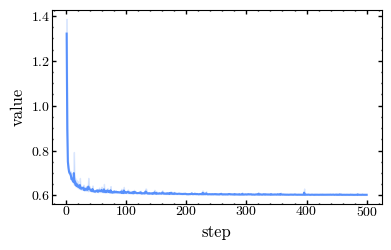

In [6]:
sns.lineplot(
    data=overall_history.filter(pl.col("metric") == "Loss").to_pandas(),
    x="step",
    y="value",
)

<Axes: xlabel='step', ylabel='value'>

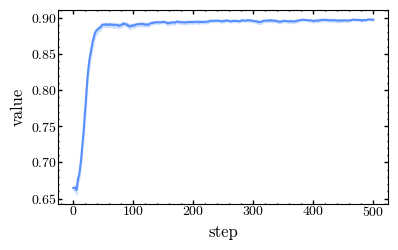

In [7]:
sns.lineplot(
    data=overall_history.filter(pl.col("metric") == "TEST: F1 Score").to_pandas(),
    x="step",
    y="value",
)

Text(0.5, 1.0, 'Mean Test ROC-AUC by Hidden Dimension')

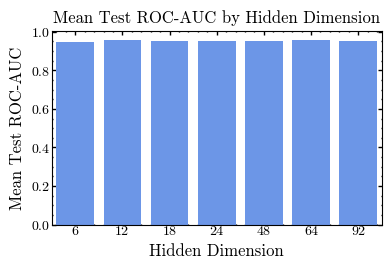

In [8]:
sns.barplot(
    data=hidden_size_df.group_by("hidden_dim").agg(pl.col("TEST: ROC-AUC").mean()).to_pandas(),
    x="hidden_dim",
    y="TEST: ROC-AUC",
)
plt.xlabel("Hidden Dimension")
plt.ylabel("Mean Test ROC-AUC")
plt.title("Mean Test ROC-AUC by Hidden Dimension")

## Directed vs Undirected

In [9]:
dir_vs_undir_df = experiment_service.get_experiment_runs_as_df(experiment_name="Dir vs Undir")
dir_vs_undir_df

run_id,TEST: ROC-AUC,TEST: F1 Score,TEST: Precision,TEST: Recall,TEST: AUC,Loss,TRAIN: AUC,TRAIN: F1 Score,TRAIN: Precision,TRAIN: ROC-AUC,TRAIN: Recall,VAL: AUC,VAL: F1 Score,VAL: Precision,VAL: ROC-AUC,VAL: Recall,epochs,hidden_dim,threshold,device,num_layers,homogeneous,directed,graphsage,experiment_name
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,str,i64,bool,bool,bool,str
"""7940bceeea614d9e8d6f11617a6075…",0.954698,0.897889,0.814881,0.999725,0.644945,0.602764,0.610652,0.84851,0.737232,0.879844,0.999353,0.646201,0.887424,0.79798,0.938799,0.99945,500,24,0.5,"""cuda""",8,true,true,true,"""Dir vs Undir"""
"""0000233c033c408686365f8839a585…",0.958177,0.897471,0.814011,1.0,0.703685,0.599161,0.735088,0.840288,0.724566,0.874936,1.0,0.627636,0.886613,0.796321,0.940697,1.0,500,24,0.5,"""cuda""",8,true,true,true,"""Dir vs Undir"""
"""e0b314e421194b4181ac0b4ba7e85c…",0.958455,0.900025,0.818223,1.0,0.629421,0.604073,0.675007,0.848593,0.737005,0.875614,1.0,0.698545,0.894905,0.8098,0.948836,1.0,500,24,0.5,"""cuda""",8,true,true,true,"""Dir vs Undir"""
"""7e3d871515584e08b4dae9c34f4129…",0.961337,0.903154,0.82341,1.0,0.82317,0.604639,0.689011,0.844709,0.731165,0.873293,1.0,0.627885,0.894685,0.809439,0.94324,1.0,500,24,0.5,"""cuda""",8,true,true,true,"""Dir vs Undir"""
"""b614e1fb16d542be80a3d6a948c815…",0.955276,0.890876,0.803224,1.0,0.704913,0.601369,0.620967,0.844709,0.731165,0.880258,1.0,0.735398,0.881027,0.787354,0.943361,1.0,500,24,0.5,"""cuda""",8,true,true,true,"""Dir vs Undir"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""6df60d829b6c44e987165124356dff…",0.954521,0.887103,0.827463,0.956008,0.702044,0.570183,0.615368,0.831549,0.736343,0.891405,0.955031,0.686601,0.876943,0.816801,0.941732,0.946645,500,24,0.5,"""cuda""",8,true,false,true,"""Dir vs Undir"""
"""a3cce279bc2f42f0902937859ed48f…",0.978543,0.873055,0.775371,0.9989,0.694835,0.564699,0.703174,0.824527,0.702241,0.909161,0.998382,0.692541,0.85921,0.75537,0.967112,0.99615,500,24,0.5,"""cuda""",8,true,false,true,"""Dir vs Undir"""
"""6057b05676d44e2798a4a3be2b65e8…",0.916678,0.878083,0.887516,0.868848,0.590563,0.560933,0.691847,0.827029,0.782395,0.867926,0.877062,0.684725,0.864495,0.86049,0.907548,0.868537,500,24,0.5,"""cuda""",8,true,false,true,"""Dir vs Undir"""


In [12]:
overall_history_dir_vs_undir = experiment_service.all_runs_history(experiment_name="Dir vs Undir")
overall_history_dir_vs_undir

Fetching Run Histories: 100%|██████████| 100/100 [00:41<00:00,  2.39run/s]


run_id,timestamp,step,metric,value
str,i64,i64,str,f64
"""7940bceeea614d9e8d6f11617a6075…",1758692846641,1,"""TEST: ROC-AUC""",0.254191
"""7940bceeea614d9e8d6f11617a6075…",1758692846777,2,"""TEST: ROC-AUC""",0.248014
"""7940bceeea614d9e8d6f11617a6075…",1758692846908,3,"""TEST: ROC-AUC""",0.272794
"""7940bceeea614d9e8d6f11617a6075…",1758692847047,4,"""TEST: ROC-AUC""",0.334705
"""7940bceeea614d9e8d6f11617a6075…",1758692847184,5,"""TEST: ROC-AUC""",0.421127
…,…,…,…,…
"""1eb0200b16cc4de7974b21362d1d16…",1758683317036,496,"""VAL: Recall""",0.948845
"""1eb0200b16cc4de7974b21362d1d16…",1758683317189,497,"""VAL: Recall""",0.930143
"""1eb0200b16cc4de7974b21362d1d16…",1758683317341,498,"""VAL: Recall""",0.926843


<Axes: xlabel='step', ylabel='value'>

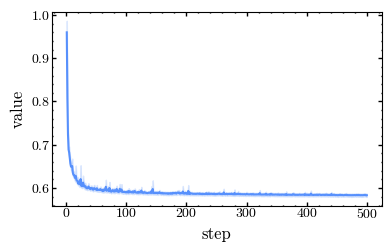

In [13]:
sns.lineplot(
    data=overall_history_dir_vs_undir.filter(pl.col("metric") == "Loss").to_pandas(),
    x="step",
    y="value",
)

Text(0.5, 1.0, 'Test F1 Score over Steps: Directed vs Undirected Graphs')

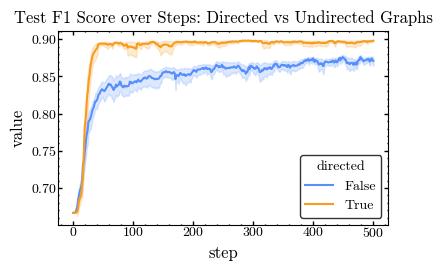

In [28]:
sns.lineplot(
    data= (
        dir_vs_undir_df.select(["run_id", "directed"]).join(
            overall_history_dir_vs_undir.filter(pl.col("metric") == "TEST: F1 Score"),
            on="run_id",
        ).to_pandas()
    ),
    x="step",
    y="value",
    hue="directed",
)
plt.title("Test F1 Score over Steps: Directed vs Undirected Graphs")